In [25]:
%load_ext autoreload
%autoreload 2

import os, sys
import matplotlib.pyplot as plt

# Load imports from the src directory
sys.path.insert(0, "../..")

from progsnap2.spec.enums import MainTableColumns as Cols
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from progsnap2.analytics.analytics_config import Granularity
from progsnap2.datasets import codeworkout, edwards, codebench, cs1eng, falconcode, pcrs, eol

# Select a dataset by setting the config variable
# config = codeworkout.S19
config = falconcode.S21
#config = pcrs.F23
#config = eol.F22_108

datasets_dir = os.path.join('..', '..', '..', 'sample_data')
dataset_paths = {
    # Edwards 2019 datasets is split into two semesters
    'edwards_f19': os.path.join(datasets_dir, 'edwards', '2019'),
    'edwards_s19': os.path.join(datasets_dir, 'edwards', '2019'),
}

if config.name in dataset_paths:
    dataset_root_dir = dataset_paths[config.name]
else:
    # Most datasets follow a simple naming convention
    dataset_name, dataset_semester = config.name.split('_')
    dataset_root_dir = os.path.join('..', '..', '..', 'sample_data', dataset_name, dataset_semester)

dataset = config.load(dataset_root_dir)

In [27]:
# Shorten some config variables for convenience
problem_id_col = config.primary_problem_grouping_column
timestamp_col = config.primary_timestamp_column

In [28]:
#For PCRS, this has to run two times.
main_table = dataset.get_main_table()
main_table.head()

# #for eol
# main_table = pd.read_csv(dataset_root_dir + "/MainTable.csv")

# for prep in config.main_table_preprocessors:
#     main_table = prep.apply(dataset, main_table)

# main_table.head()

,id,SubjectID,course_id,ProblemID,ServerTimestamp,Score,CodeStateID
32477,32478,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,3,Airstrike,2021-11-23 17:56:17,-1.0,9bde7cacf32d1ac59416b25b42eb49a668622be4
32470,32471,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,3,Airstrike,2021-11-23 17:57:00,-1.0,4d162588968f100bf2993301a3d1f2cb3a9ecf57
32456,32457,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,3,Airstrike,2021-11-23 17:58:13,-1.0,67e88bdabae3cd4a4b03f67c9f159d49afcb1f1d
32400,32401,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,3,Airstrike,2021-11-23 18:03:35,-1.0,0b57dd807396cb4edd500aa3d9fb55b4ac974c57
32395,32396,000f96b7-ba0e-43ce-a5c3-c8fc0a6406f0,3,Airstrike,2021-11-23 18:03:48,-1.0,2758e8c3ff3aa284939a1ff5c9011c8b5e86e3d7


In [29]:
if config.start_time is not None:
    main_table = main_table[main_table[timestamp_col] >= config.start_time]
if config.end_time is not None:
    main_table = main_table[main_table[timestamp_col] <= config.end_time]

In [30]:
# convert Score to numeric
if main_table["Score"].dtype == object:
    main_table["Score"] = pd.to_numeric(main_table["Score"], errors='coerce')

In [31]:
# Used for converting percentages to raw early time when
# creating a dataset config; not needed when using existing configs
min = main_table[timestamp_col].min()
max = main_table[timestamp_col].max()
min + (max - min) * 0.29

Timestamp('2021-02-11 17:43:36.410000')

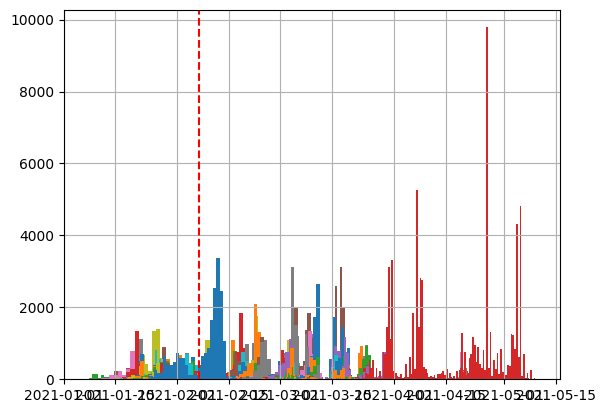

In [32]:
assignment_col = Cols.AssignmentID if Cols.AssignmentID in main_table.columns else problem_id_col
early_timestamp = pd.to_datetime(config.early_time)
if early_timestamp is None:
    print("Warning: No early time cutoff specified")
if Cols.CourseSectionID not in main_table.columns:
    main_table.groupby(assignment_col)[timestamp_col].hist(bins=100)
    if early_timestamp is not None:
        plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
else:
    classes = main_table[Cols.CourseSectionID].unique()
    classes = classes[~pd.isna(classes)]
    for class_id in classes:
        subset = main_table[main_table[Cols.CourseSectionID] == class_id]
        hist = subset.groupby(assignment_col)[timestamp_col].hist(bins=100)
        plt.title(f"Class {class_id}")
        if early_timestamp is not None:
            plt.axvline(x=early_timestamp, color='r', linestyle='--', label='Early Time Cutoff')
        plt.show()

/Users/samarwan/ProgSnapToolbox/src/progsnap2/examples/../../progsnap2/analytics/preprocessors/early_cutoff.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  problem_percentages = main_table[main_table[problem_ID_column].isin(included_problem_ids)].groupby(problem_ID_column).apply(lambda x: (x[timestamp_col] < time_cutoff).mean())


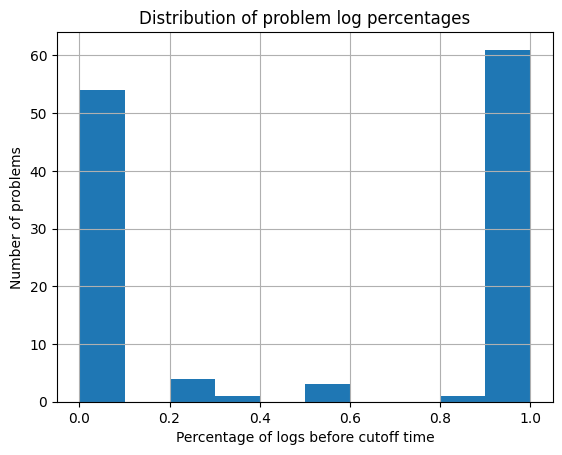

Removing partial problems: Index(['PEX1', 'pex1', 'lsn11_imagesize', 'lsn11_callme', 'lsn11_triangle',
       'lsn12_skill1', 'lsn12_asteroids', 'lsn13_dvc', 'lsn12_skill2',
       'lsn13_squadrons', 'lsn12_circle', 'lsn12_in_circle', 'lsn12_distance',
       'lsn14_printchars', 'lsn14_counting', 'lsn13_skill1', 'lsn13_waittimes',
       'lsn15_titanicfares', 'lsn15_runways', 'lsn13_averagerun',
       'lsn13_skill2', 'lsn13_countby10s', 'lsn13_count',
       'lsn13_cargocapacity', 'lsn14_skill1', 'lsn14_timestable',
       'lsn18_grades', 'lsn14_coordinates', 'lsn14_skill2', 'lsn19_golf',
       'lsn18_namesreverse', 'lsn15_survivors_by_gender', 'lsn15_skill1',
       'lsn14_football', 'lsn15_echo', 'lsn19_movies', 'lsn19_population',
       'lsn15_skill2', 'lsn16_practice4', 'lsn20_averagetraffic',
       'lsn18_names', 'lsn16_practice2', 'lsn20_lowvolume', 'lsn19_skill1',
       'lsn14_class2017', 'lsn19_credit', 'lsn20_unpopularnames',
       'lsn16_practice1', 'lsn19_skill2', 'lsn

In [33]:
from progsnap2.analytics.preprocessors.early_cutoff import filter_before_time

data_subset = filter_before_time(main_table, config.early_time, timestamp_col, filter_problems=True, verbose=True)

In [34]:
# We want to analyze each student's attempt at each problem, and we also
# want to analyze data separately from each course section.
grouping_cols = config.attempt_grouping_columns
grouping_cols = [col for col in grouping_cols if col in main_table.columns]
grouping_cols

[<MainTableColumns.SubjectID: 'SubjectID'>,
 <MainTableColumns.ProblemID: 'ProblemID'>]

In [35]:
print(len(data_subset["SubjectID"].unique()))
print(len(data_subset[problem_id_col].unique()))

494
65


In [36]:
from progsnap2.analytics.metrics.errors import ErrorMetrics

error_results = None

if Cols.ParentEventID in data_subset.columns:
    error_metrics = ErrorMetrics(True,
                                compile_message_type_column=config.compile_error_type_column,
                                compile_event=config.compile_event,
                                compile_error_event=config.compile_error_event)

    error_results = data_subset.groupby(grouping_cols).apply(error_metrics.calculate)
    error_results.head()

In [37]:
if error_results is not None:
    # Distribution of each error metric across students/problems
    error_results.describe()

In [38]:
if error_results is not None:
    # Correlate the metrics
    error_results.corr(method="spearman")

In [ ]:
print(error_results.head(20))

<Axes: ylabel='Frequency'>

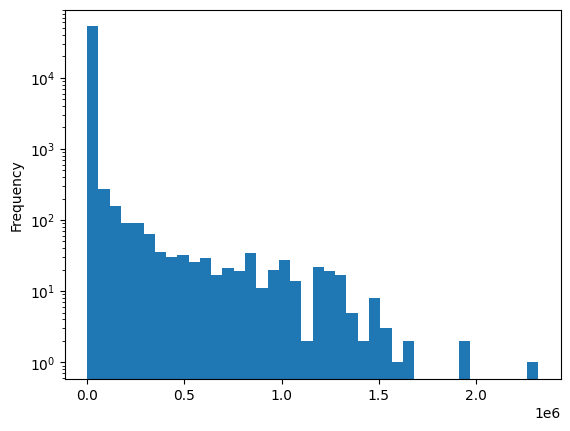

In [39]:
from progsnap2.analytics.metrics.time import TimeMetrics

# Out of curisosity, how far apart are events in this dataset (in seconds)?
diffs = TimeMetrics.get_all_diffs(data_subset, timestamp_col, grouping_cols)
diffs.DeltaSeconds[diffs.DeltaSeconds > 0].plot.hist(bins=40, log=True)

In [40]:
# Determine a gap to be considered idle time or taking a break based
# on the type of dataset. Can confirm with the histogram above if it makes sense
idle_gap = None
break_gap = None
if config.granularity == Granularity.Submission:
    idle_gap = 5 * 60  # 5 minutes
    break_gap = 30 * 60  # 30 minutes
elif config.granularity == Granularity.Edit or config.granularity == Granularity.Keystroke:
    idle_gap = 30
    break_gap = 3 * 60 # 3 minutes
else:
    raise NotImplementedError(f"{config.granularity} granularity has not been determined.")


In [41]:
from progsnap2.analytics.metrics.time import TimeMetrics
time_metrics = TimeMetrics(idle_gap, break_gap, True, timestamp_col)

time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))
time_results

/var/folders/fh/j8r_pl3s1fl6hzg7s5qcxc3m0000gp/T/ipykernel_90640/1574692767.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  time_results = data_subset.groupby(grouping_cols).apply(lambda x: time_metrics.calculate(x))


ActiveTime  PassiveTime  \
SubjectID                            ProblemID                                 
007f6785-388a-4dee-8cc8-e1c903fd78e2 a1_1_dorms             0.0          0.0   
                                     a1_3_radius           15.0          0.0   
                                     a1_4_cards             0.0          0.0   
                                     a1_6_printer           0.0          0.0   
                                     a1_7_broadband       124.0          0.0   
...                                                         ...          ...   
ff18e8e8-9f0c-4483-be47-510e69c9beb4 lsn8_fuel              0.0          0.0   
                                     lsn8_roundtrip         0.0          0.0   
                                     lsn8_skill1            0.0          0.0   
                                     lsn8_skill2          119.0          0.0   
                                     lsn8_uod               0.0          0.0   

                                                     TotalTime  \
SubjectID                            ProblemID                   
007f6785-388a-4dee-8cc8-e1c903fd78e2 a1_1_dorms            0.0   
                                     a1_3_radius          15.0   
                                     a1_4_cards            0.0   
                                     a1_6_printer          0.0   
                                     a1_7_broadband      124.0   
...                                                        ...   
ff18e8e8-9f0c-4483-be47-510e69c9beb4 lsn8_fuel             0.0   
                                     lsn8_roundtrip        0.0   
                                     lsn8_skill1           0.0   
                                     lsn8_skill2         119.0   
                                     lsn8_uod              0.0   

                                                     ActiveTimeAfterCorrect  \
SubjectID                            ProblemID                                
007f6785-388a-4dee-8cc8-e1c903fd78e2 a1_1_dorms                         0.0   
                                     a1_3_radius                        0.0   
                                     a1_4_cards                         0.0   
                                     a1_6_printer                       0.0   
                                     a1_7_broadband                    53.0   
...                                                                     ...   
ff18e8e8-9f0c-4483-be47-510e69c9beb4 lsn8_fuel                        383.0   
                                     lsn8_roundtrip                   320.0   
                                     lsn8_skill1                        0.0   
                                     lsn8_skill2                      141.0   
                                     lsn8_uod                         539.0   

                                                     #Breaks  \
SubjectID                            ProblemID                 
007f6785-388a-4dee-8cc8-e1c903fd78e2 a1_1_dorms            0   
                                     a1_3_radius           0   
                                     a1_4_cards            0   
                                     a1_6_printer          0   
                                     a1_7_broadband        0   
...                                                      ...   
ff18e8e8-9f0c-4483-be47-510e69c9beb4 lsn8_fuel             0   
                                     lsn8_roundtrip        0   
                                     lsn8_skill1           0   
                                     lsn8_skill2           0   
                                     lsn8_uod              0   

                                                              StartTime  \
SubjectID                            ProblemID                            
007f6785-388a-4dee-8cc8-e1c903fd78e2 a1_1_dorms     2021-02-04 21:18:24   
                                     a1_3_radius    2021-02-04 21:2

In [42]:
time_results.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
count,18073.00000,18073.000000,18073.000000,18073.000000,18073.000000,18073,17579,18073
mean,95.65335,62.327339,157.980689,51.300116,0.038621,2021-01-27 07:07:25.952913152,2021-01-27 05:50:43.716878080,2021-01-27 14:10:41.321639936
min,0.00000,0.000000,0.000000,0.000000,0.000000,2021-01-07 03:11:28,2021-01-07 03:11:28,2021-01-07 03:14:24
25%,0.00000,0.000000,0.000000,0.000000,0.000000,2021-01-22 09:47:35,2021-01-22 09:58:13,2021-01-22 11:08:00
50%,0.00000,0.000000,0.000000,0.000000,0.000000,2021-01-27 09:05:38,2021-01-27 08:08:19,2021-01-27 11:19:51
75%,79.00000,0.000000,93.000000,0.000000,0.000000,2021-02-02 01:42:41,2021-02-01 21:37:53.500000,2021-02-02 12:13:32
max,6747.00000,8372.000000,15119.000000,2990.000000,6.000000,2021-02-06 14:27:54,2021-02-06 14:27:54,2021-02-06 14:31:06
std,234.27487,277.665593,434.744414,180.790080,0.232992,NaN,NaN,NaN


In [43]:
time_results.corr(method="spearman")

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime
ActiveTime,1.000000,0.349854,0.968186,-0.038146,0.238508,-0.089864,-0.136851,-0.070131
PassiveTime,0.349854,1.000000,0.492570,0.011316,0.204794,0.016278,-0.040841,0.028204
TotalTime,0.968186,0.492570,1.000000,-0.026706,0.240736,-0.074897,-0.128410,-0.055620
ActiveTimeAfterCorrect,-0.038146,0.011316,-0.026706,1.000000,-0.009238,0.062342,0.089864,0.095497
#Breaks,0.238508,0.204794,0.240736,-0.009238,1.000000,-0.058849,-0.056192,-0.023294
StartTime,-0.089864,0.016278,-0.074897,0.062342,-0.058849,1.000000,0.919533,0.966970
FirstCorrectTime,-0.136851,-0.040841,-0.128410,0.089864,-0.056192,0.919533,1.000000,0.890630
EndTime,-0.070131,0.028204,-0.055620,0.095497,-0.023294,0.966970,0.890630,1.000000


In [ ]:
from progsnap2.analytics.metrics.score import SubmissionScoreMetrics
from progsnap2.spec.enums import EventType

score_metrics = SubmissionScoreMetrics(config.submit_event)

subject_problem_score = data_subset.groupby(grouping_cols).apply(lambda x: score_metrics.calculate(x))


In [99]:
subject_problem_score.head()

Attempts  \
SubjectID                            ProblemID                      
007f6785-388a-4dee-8cc8-e1c903fd78e2 lsn1_helloworld            1   
                                     lsn4_ascii                 6   
                                     lsn4_parking               1   
                                     lsn4_printpractice         1   
                                     lsn5_arrivaltime           2   

                                                         FirstCorrect  \
SubjectID                            ProblemID                          
007f6785-388a-4dee-8cc8-e1c903fd78e2 lsn1_helloworld             True   
                                     lsn4_ascii                 False   
                                     lsn4_parking                True   
                                     lsn4_printpractice          True   
                                     lsn5_arrivaltime           False   

                                                         EverCorrect  \
SubjectID                            ProblemID                         
007f6785-388a-4dee-8cc8-e1c903fd78e2 lsn1_helloworld            True   
                                     lsn4_ascii                 True   
                                     lsn4_parking               True   
                                     lsn4_printpractice         True   
                                     lsn5_arrivaltime           True   

                                                         Attempted  MaxScore  \
SubjectID                            ProblemID                                 
007f6785-388a-4dee-8cc8-e1c903fd78e2 lsn1_helloworld          True     100.0   
                                     lsn4_ascii               True     100.0   
                                     lsn4_parking             True     100.0   
                                     lsn4_printpractice       True     100.0   
                                     lsn5_arrivaltime         True     100.0   

                                                         MinScore   MeanScore  \
SubjectID                            ProblemID                                  
007f6785-388a-4dee-8cc8-e1c903fd78e2 lsn1_helloworld        100.0  100.000000   
                                     lsn4_ascii               0.0   16.666667   
                                     lsn4_parking            50.0   50.000000   
                                     lsn4_printpractice      42.0   42.000000   
                                     lsn5_arrivaltime         0.0   50.000000   

                                                         FirstScore  \
SubjectID                            ProblemID                        
007f6785-388a-4dee-8cc8-e1c903fd78e2 lsn1_helloworld          100.0   
                                     lsn4_ascii                 0.0   
                                     lsn4_parking              50.0   
                                     lsn4_printpractice        42.0   
                                     lsn5_arrivaltime           0.0   

                                                         TotalAttempts  
SubjectID                            ProblemID                          
007f6785-388a-4dee-8cc8-e1c903fd78e2 lsn1_helloworld                 3  
                                     lsn4_ascii                      6  
                                     lsn4_parking                    3  
                                     lsn4_printpractice              2  
                                     lsn5_arrivaltime                3

In [100]:
subject_problem_score.describe()

,Attempts,MaxScore,MinScore,MeanScore,FirstScore,TotalAttempts
count,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000
mean,2.960557,97.835454,50.861285,60.549235,50.861285,4.817980
std,5.112056,14.047630,46.352713,37.515794,46.352713,6.631329
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,100.000000,0.000000,25.000000,0.000000,1.000000
50%,1.000000,100.000000,50.000000,50.000000,50.000000,3.000000
75%,3.000000,100.000000,100.000000,100.000000,100.000000,6.000000
max,157.000000,100.000000,100.000000,100.000000,100.000000,165.000000


In [ ]:
all_features = pd.merge(
    time_results.reset_index(),
    subject_problem_score.reset_index(),
    on=grouping_cols,
    how="outer"
)
if error_results is not None:
    all_features = pd.merge(
        all_features,
        error_results.reset_index(),
        on=grouping_cols,
        how="outer"
    )
all_features.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,FirstScore,TotalAttempts
0,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn1_helloworld,0.0,0.0,0.0,0.0,0,2021-01-09 06:56:39,2021-01-09 06:56:39,2021-01-09 06:56:39,1,True,True,True,100.0,100.0,100.000000,100.0,3
1,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn4_ascii,704.0,0.0,704.0,0.0,0,2021-01-18 04:08:25,2021-01-18 04:20:09,2021-01-18 04:20:09,6,False,True,True,100.0,0.0,16.666667,0.0,6
2,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn4_parking,0.0,0.0,0.0,75.0,0,2021-01-18 04:22:34,2021-01-18 04:22:34,2021-01-18 04:24:21,1,True,True,True,100.0,50.0,50.000000,50.0,3
3,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn4_printpractice,0.0,0.0,0.0,0.0,0,2021-01-18 04:34:14,2021-01-18 04:34:14,2021-01-18 04:35:43,1,True,True,True,100.0,42.0,42.000000,42.0,2
4,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn5_arrivaltime,145.0,0.0,145.0,0.0,0,2021-01-18 06:15:46,2021-01-18 06:18:11,2021-01-21 21:29:22,2,False,True,True,100.0,0.0,50.000000,0.0,3


In [103]:
# Some features are NA for some students, e.g. because
# they never got a problem right (no FirstCorrectTime) or
# because they only compiled once and errors metrics are undefined.
all_features.isna().mean()

SubjectID                 0.000000
ProblemID                 0.000000
ActiveTime                0.000000
PassiveTime               0.000000
TotalTime                 0.000000
ActiveTimeAfterCorrect    0.000000
#Breaks                   0.000000
StartTime                 0.000000
FirstCorrectTime          0.018424
EndTime                   0.000000
Attempts                  0.000000
FirstCorrect              0.000000
EverCorrect               0.000000
Attempted                 0.000000
MaxScore                  0.000000
MinScore                  0.000000
MeanScore                 0.000000
FirstScore                0.000000
TotalAttempts             0.000000
dtype: float64

In [104]:
median_features = all_features.groupby(problem_id_col)[[TimeMetrics.ACTIVE_TIME, SubmissionScoreMetrics.MAX_SCORE]].median()
all_features_with_median = all_features.merge(
    median_features,
    on=problem_id_col,
    suffixes=("", "_median"),
    how="left"
)

# We can calculate a few custom metrics
all_features["AtLeatMedianActiveTime"] = (all_features[TimeMetrics.ACTIVE_TIME] >= all_features_with_median[TimeMetrics.ACTIVE_TIME + "_median"]) + 0
all_features["AtLeatMedianMaxScore"] = (all_features[SubmissionScoreMetrics.MAX_SCORE] >= all_features_with_median[SubmissionScoreMetrics.MAX_SCORE + "_median"]) + 0
all_features["HadEffort"] = all_features["AtLeatMedianActiveTime"] | all_features["AtLeatMedianMaxScore"]
all_features.describe()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,MaxScore,MinScore,MeanScore,FirstScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
count,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000,15795,15504,15795,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000,15795.000000
mean,99.581893,57.612726,157.194619,53.331561,0.043178,2021-01-26 02:27:50.017600512,2021-01-26 03:04:50.460075008,2021-01-26 10:31:00.906236160,2.960557,97.835454,50.861285,60.549235,50.861285,4.817980,0.808737,0.974486,0.995758
min,0.000000,0.000000,0.000000,0.000000,0.000000,2021-01-07 03:11:28,2021-01-07 03:11:28,2021-01-07 03:14:24,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,2021-01-22 01:55:44.500000,2021-01-22 02:40:12.249999872,2021-01-22 04:00:32,1.000000,100.000000,0.000000,25.000000,0.000000,1.000000,1.000000,1.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,2021-01-26 09:41:00,2021-01-26 10:08:26,2021-01-26 11:52:39,1.000000,100.000000,50.000000,50.000000,50.000000,3.000000,1.000000,1.000000,1.000000
75%,82.000000,0.000000,97.000000,0.000000,0.000000,2021-01-29 10:53:54,2021-01-29 10:57:27,2021-01-29 21:20:43,3.000000,100.000000,100.000000,100.000000,100.000000,6.000000,1.000000,1.000000,1.000000
max,6747.000000,8372.000000,15119.000000,2990.000000,6.000000,2021-02-06 14:27:54,2021-02-06 14:27:54,2021-02-06 14:31:06,157.000000,100.000000,100.000000,100.000000,100.000000,165.000000,1.000000,1.000000,1.000000
std,243.820418,268.153079,435.331121,183.683517,0.246869,NaN,NaN,NaN,5.112056,14.047630,46.352713,37.515794,46.352713,6.631329,0.393308,0.157686,0.064993


In [105]:
import numpy as np

# Let's take the z-score per problem for each numeric feature to
# normalize the features before combining across problems.
all_features_z = all_features.copy()

time_cols = [
    TimeMetrics.START_TIME,
    TimeMetrics.FIRST_CORRECT_TIME,
    TimeMetrics.END_TIME,
]

for col in time_cols:
    all_features_z[col] = all_features_z[col].astype('int64') / 1e9
    # int64 will automatically convert NaN to 0, so we reinsert them
    all_features_z.loc[all_features[col].isna(), col] = np.nan
numeric_cols = all_features_z.select_dtypes(include=["number"]).columns
# remove the grouping columns from numeric_cols
numeric_cols = numeric_cols.difference(grouping_cols)
all_features_z[numeric_cols] = all_features_z.groupby(problem_id_col)[numeric_cols].transform(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1))


In [106]:
all_features_z.head()

,SubjectID,ProblemID,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,...,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,FirstScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
0,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn1_helloworld,-0.108811,0.000000,-0.108811,-0.411691,0.000000,-0.674436,-0.674439,-0.802577,...,True,True,0.000000,0.066082,0.066082,0.066082,-0.542698,0.000000,0.000000,0.000000
1,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn4_ascii,2.429618,-0.253763,1.150033,-0.133857,-0.241871,-0.437292,-0.419952,-0.461306,...,True,True,0.250360,-0.619156,-0.741991,-0.619156,0.067125,0.996150,0.250360,0.178181
2,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn4_parking,-0.723275,-0.298456,-0.558489,0.338992,-0.276410,-0.386329,-0.413360,-0.450256,...,True,True,0.094073,0.572099,0.222170,0.572099,-0.507659,-1.005509,0.094073,0.066372
3,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn4_printpractice,-0.318654,-0.235759,-0.322748,-0.773323,-0.142057,-0.422540,-0.419723,-0.466886,...,True,True,0.139800,0.112050,0.069127,0.112050,-0.794313,0.000000,0.157404,0.000000
4,007f6785-388a-4dee-8cc8-e1c903fd78e2,lsn5_arrivaltime,-0.161881,-0.309080,-0.265013,-0.189217,-0.261915,-1.662141,-1.693692,-0.256566,...,True,True,0.081290,-0.678621,-0.051676,-0.678621,-0.257873,0.998903,0.081290,0.081290


In [ ]:
merge_cols = grouping_cols.copy()
merge_cols = [col for col in merge_cols if col not in [Cols.ProblemID, Cols.AssignmentID]]
merge_cols = [col for col in merge_cols if col in all_features_z.columns]
drop_cols = [col for col in [Cols.ProblemID, Cols.AssignmentID] if col in all_features_z.columns]

# Take the average across all problems for each student
subject_means = all_features_z.drop(drop_cols, axis=1).groupby(merge_cols).mean()

# Sometimes there are no non-NA values for a student across all problems for a given
# feature and we need to deal with that.

# For EQ and RED having no attempts with a successful compile (and therefore a score)
# should give you the max (worst) value
# Similarly, never getting a problem correct should give you the max (worst) value for FirstCorrectTime
for col in [ErrorMetrics.ERROR_QUOTIENT, ErrorMetrics.REPEATED_ERROR_DENSITY, TimeMetrics.FIRST_CORRECT_TIME]:
    if col not in subject_means.columns:
        continue
    max_val = subject_means[col].max()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(max_val)

# But for score metrics, not trying a problem should lead to the minimum value
for col in [SubmissionScoreMetrics.MAX_SCORE, SubmissionScoreMetrics.MEAN_SCORE, SubmissionScoreMetrics.MIN_SCORE]:
    min_val = subject_means[col].min()
    subject_means.iloc[:, subject_means.columns.get_loc(col)] = subject_means[col].fillna(min_val)

subject_means.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,FirstScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,
007f6785-388a-4dee-8cc8-e1c903fd78e2,-0.211553,-0.192148,-0.245112,-0.110848,-0.104609,-0.587721,-0.577410,-0.570183,-0.252558,0.675676,1.000000,1.0,0.146564,0.153389,0.194483,0.153389,-0.235761,-0.054927,0.153602,0.036926
00c3a4b3-fc20-4d16-8b10-8e3d00938ba9,0.265935,0.398670,0.417813,0.395105,-0.050949,-0.879546,-0.852060,-0.445102,0.221070,0.611111,1.000000,1.0,0.131865,-0.084186,-0.211582,-0.084186,0.476042,0.137688,0.137354,0.030514
01c4ce91-6adb-4380-b6d4-9f0e2ab023e6,0.885131,0.542985,0.760734,0.543426,0.126720,0.670724,0.659201,0.411925,0.718542,0.523810,0.952381,1.0,-0.512832,-0.052934,-0.204828,-0.052934,0.632366,0.093543,-0.559242,0.039373
021e499a-be6a-4b9a-8bcc-d5a2324e82fd,-0.076991,-0.012701,-0.052285,-0.072243,-0.011246,-0.277211,-0.256994,-0.291295,0.093924,0.500000,1.000000,1.0,0.146090,-0.259713,-0.251500,-0.259713,0.104958,0.073887,0.152672,0.036890
0256fa1f-5ccc-4fc9-ae02-ee6743909347,0.017061,-0.143959,-0.140318,-0.043683,-0.119680,1.729772,1.718169,1.173147,-0.009525,0.625000,1.000000,1.0,0.095827,-0.611214,-0.511617,-0.611214,-0.051160,-0.125689,0.103818,0.008297


In [108]:
# We can also take the sum of features across problems, which treats
# missing problems differently than the mean.
subject_totals = all_features_z.drop(drop_cols, axis=1).groupby(merge_cols).sum()
subject_totals.head()

,ActiveTime,PassiveTime,TotalTime,ActiveTimeAfterCorrect,#Breaks,StartTime,FirstCorrectTime,EndTime,Attempts,FirstCorrect,EverCorrect,Attempted,MaxScore,MinScore,MeanScore,FirstScore,TotalAttempts,AtLeatMedianActiveTime,AtLeatMedianMaxScore,HadEffort
SubjectID,,,,,,,,,,,,,,,,,,,,
007f6785-388a-4dee-8cc8-e1c903fd78e2,-7.827464,-7.109478,-9.069155,-4.101388,-3.870545,-21.745671,-21.364184,-21.096761,-9.344640,25,37,37,5.422868,5.675386,7.195874,5.675386,-8.723161,-2.032301,5.683267,1.366273
00c3a4b3-fc20-4d16-8b10-8e3d00938ba9,9.573647,14.352119,15.041284,14.223770,-1.834178,-31.663667,-30.674168,-16.023687,7.958516,22,36,36,4.747150,-3.030694,-7.616966,-3.030694,17.137507,4.956783,4.944755,1.098489
01c4ce91-6adb-4380-b6d4-9f0e2ab023e6,18.587746,11.402688,15.975424,11.411945,2.661111,14.085207,13.184016,8.650435,15.089385,11,20,21,-10.769464,-1.111621,-4.301380,-1.111621,13.279688,1.964393,-11.744081,0.826836
021e499a-be6a-4b9a-8bcc-d5a2324e82fd,-3.079657,-0.508054,-2.091381,-2.889721,-0.449845,-11.088424,-10.279758,-11.651812,3.756961,20,40,40,5.843590,-10.388525,-10.060001,-10.388525,4.198314,2.955468,6.106874,1.475600
0256fa1f-5ccc-4fc9-ae02-ee6743909347,0.136491,-1.151673,-1.122544,-0.349465,-0.957437,13.838173,13.745350,9.385176,-0.076196,5,8,8,0.766618,-4.889712,-4.092937,-4.889712,-0.409284,-1.005509,0.830546,0.066372


In [109]:
# Lets merge the means and totals into a single DataFrame
subject_features = pd.merge(
    subject_means.reset_index(),
    subject_totals.reset_index(),
    on=merge_cols,
    how="outer",
    suffixes=('_mean', '_sum')
)
subject_features.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,FirstScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,007f6785-388a-4dee-8cc8-e1c903fd78e2,-0.211553,-0.192148,-0.245112,-0.110848,-0.104609,-0.587721,-0.577410,-0.570183,-0.252558,...,37,37,5.422868,5.675386,7.195874,5.675386,-8.723161,-2.032301,5.683267,1.366273
1,00c3a4b3-fc20-4d16-8b10-8e3d00938ba9,0.265935,0.398670,0.417813,0.395105,-0.050949,-0.879546,-0.852060,-0.445102,0.221070,...,36,36,4.747150,-3.030694,-7.616966,-3.030694,17.137507,4.956783,4.944755,1.098489
2,01c4ce91-6adb-4380-b6d4-9f0e2ab023e6,0.885131,0.542985,0.760734,0.543426,0.126720,0.670724,0.659201,0.411925,0.718542,...,20,21,-10.769464,-1.111621,-4.301380,-1.111621,13.279688,1.964393,-11.744081,0.826836
3,021e499a-be6a-4b9a-8bcc-d5a2324e82fd,-0.076991,-0.012701,-0.052285,-0.072243,-0.011246,-0.277211,-0.256994,-0.291295,0.093924,...,40,40,5.843590,-10.388525,-10.060001,-10.388525,4.198314,2.955468,6.106874,1.475600
4,0256fa1f-5ccc-4fc9-ae02-ee6743909347,0.017061,-0.143959,-0.140318,-0.043683,-0.119680,1.729772,1.718169,1.173147,-0.009525,...,8,8,0.766618,-4.889712,-4.092937,-4.889712,-0.409284,-1.005509,0.830546,0.066372


In [110]:
subject_features.isna().mean()[subject_features.isna().mean() != 0]

Series([], dtype: float64)

In [111]:
# No feature should be NA at this point
assert subject_features.isna().mean().mean() == 0

In [112]:
# Take one last z-score across all students for each numeric feature
# This makes means and sums more comparable across students
subject_feautres_z = subject_features.copy()
numeric_cols = subject_feautres_z.select_dtypes(include=["number"]).columns
numeric_cols = numeric_cols.difference(merge_cols)
subject_feautres_z[numeric_cols] = subject_feautres_z[numeric_cols].apply(lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1), axis=0)
subject_feautres_z.head()

,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,EverCorrect_sum,Attempted_sum,MaxScore_sum,MinScore_sum,MeanScore_sum,FirstScore_sum,TotalAttempts_sum,AtLeatMedianActiveTime_sum,AtLeatMedianMaxScore_sum,HadEffort_sum
0,007f6785-388a-4dee-8cc8-e1c903fd78e2,-0.501077,-0.706592,-0.683069,-0.380949,-0.398482,-0.887159,-0.874252,-0.929574,-0.774276,...,0.654252,0.614014,0.422155,0.536578,0.620814,0.536578,-0.678885,-0.391070,0.464923,0.344299
1,00c3a4b3-fc20-4d16-8b10-8e3d00938ba9,0.499957,1.331156,1.017075,1.403077,-0.208738,-1.283588,-1.247832,-0.743004,0.612565,...,0.529145,0.483395,0.369552,-0.286536,-0.657143,-0.286536,1.333736,0.953820,0.404509,0.276818
2,01c4ce91-6adb-4380-b6d4-9f0e2ab023e6,1.798077,1.828903,1.896533,1.926068,0.419505,0.822367,0.807792,0.535344,2.069225,...,-1.472581,-1.475882,-0.838372,-0.105098,-0.371096,-0.105098,1.033499,0.378003,-0.960732,0.208362
3,021e499a-be6a-4b9a-8bcc-d5a2324e82fd,-0.218974,-0.087675,-0.188542,-0.244824,-0.068346,-0.465349,-0.438420,-0.513584,0.240266,...,1.029576,1.005869,0.454907,-0.982180,-0.867913,-0.982180,0.326736,0.568713,0.499577,0.371850
4,0256fa1f-5ccc-4fc9-ae02-ee6743909347,-0.021796,-0.540387,-0.414313,-0.144120,-0.451771,2.261024,2.248206,1.670786,-0.062644,...,-2.973875,-3.173922,0.059679,-0.462296,-0.353112,-0.462296,-0.031853,-0.193487,0.067943,0.016726


In [113]:
data_subset.columns

Index(['CodeStateID', 'SubjectID', 'course_id', 'ProblemID', 'Score',
       'ServerTimestamp', 'EventType'],
      dtype='object')

In [114]:
from progsnap2.analytics.preprocessors.codestates import get_latest_max_score

# get latest max score
latest_max_score = get_latest_max_score(
    data_subset,
    sort_by_cols=[Cols.SubjectID, problem_id_col, Cols.Score, timestamp_col], 
    group_by_cols=[Cols.SubjectID, problem_id_col])


In [ ]:
# load code states
code_states = dataset.get_codestates(latest_max_score)


In [17]:
print(len(code_states))
code_states.head()

229483


,EventID,SubjectID,AssignmentID,CourseID,SubmissionID,EventType,CodeStateID,ParentEventID,ClientTimestamp,ClientTimezone,...,ProgramErrorOutput,InterventionCategory,InterventionType,InterventionMessage,ServerTimestamp,ServerTimezone,ToolInstances,Filename,Contents,Hashed
0,7236578,Aipom,bakery_functions_builtins_code_dashing_name,22F-CISC108-010,339383,Session.Start,58793,NaN,2022-09-08 15:13:10.289,240.0,...,NaN,NaN,NaN,NaN,2022-09-08 19:13:55.402840,500,BPY5,answer.py,"filename = ""01-All-The-Single-Ladies.mp3"".repl...",01f25df2c8dae676967ba6cc64b028d96f5a35bc7610a0...
1,7236578,Aipom,bakery_functions_builtins_code_dashing_name,22F-CISC108-010,339383,Session.Start,58793,NaN,2022-09-08 15:13:10.289,240.0,...,NaN,NaN,NaN,NaN,2022-09-08 19:13:55.402840,500,BPY5,evaluations,"""01-All-The-Single-Ladies.mp3"".replace(""-"","" "")",01f25df2c8dae676967ba6cc64b028d96f5a35bc7610a0...
2,7236578,Aipom,bakery_functions_builtins_code_dashing_name,22F-CISC108-010,339383,Session.Start,58793,NaN,2022-09-08 15:13:10.289,240.0,...,NaN,NaN,NaN,NaN,2022-09-08 19:13:55.402840,500,BPY5,answer.py,"filename = ""01-All-The-Single-Ladies.mp3"".repl...",01f25df2c8dae676967ba6cc64b028d96f5a35bc7610a0...
3,7236578,Aipom,bakery_functions_builtins_code_dashing_name,22F-CISC108-010,339383,Session.Start,58793,NaN,2022-09-08 15:13:10.289,240.0,...,NaN,NaN,NaN,NaN,2022-09-08 19:13:55.402840,500,BPY5,evaluations,"""01-All-The-Single-Ladies.mp3"".replace(""-"","" "")",01f25df2c8dae676967ba6cc64b028d96f5a35bc7610a0...
4,7236578,Aipom,bakery_functions_builtins_code_dashing_name,22F-CISC108-010,339383,Session.Start,58793,NaN,2022-09-08 15:13:10.289,240.0,...,NaN,NaN,NaN,NaN,2022-09-08 19:13:55.402840,500,BPY5,answer.py,"filename = ""01-All-The-Single-Ladies.mp3"".repl...",01f25df2c8dae676967ba6cc64b028d96f5a35bc7610a0...


In [18]:
from progsnap2.analytics.metrics.code import CodeMetricsProcessor

# run code metrics
code_metrics = config.code_metrics_processor.parallel_calculate(code_states.head(1000))

INFO: Pandarallel will run on 6 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [19]:
from progsnap2.analytics.preprocessors.codestates import merge_metrics_with_data_subset, get_metrics_sum_and_averages, get_metrics_z_scores

# merge metrics with data
data_code = merge_metrics_with_data_subset(latest_max_score, code_metrics)

# calculate sum and averages
code_metrics_sum_and_averages = get_metrics_sum_and_averages(data_code, group_by=Cols.SubjectID, code_metrics_columns=config.code_metrics_processor.code_metrics_columns())

# calculate z-scores
code_metrics_z_scores = get_metrics_z_scores(code_metrics_sum_and_averages)

In [20]:
code_metrics_z_scores.head()

,SubjectID,N1_mean,N1_sum,N2_mean,N2_sum,avg_cc_mean,avg_cc_sum,bugs_mean,bugs_sum,calculated_length_mean,...,loc_mean,loc_sum,sloc_mean,sloc_sum,time_mean,time_sum,vocabulary_mean,vocabulary_sum,volume_mean,volume_sum
0,Aipom,-0.760449,-0.210829,-0.760150,-0.210812,-0.447998,-0.142898,-0.695996,-0.196907,-0.645477,...,0.008013,2.253527,-0.014482,2.405841,-0.539778,-0.160667,-0.769063,-0.211686,-0.695996,-0.196907
1,Alomomola,-0.760449,-0.210829,-0.760150,-0.210812,-0.447998,-0.142898,-0.695996,-0.196907,-0.645477,...,0.275849,2.132486,0.062278,1.941585,-0.539778,-0.160667,-0.769063,-0.211686,-0.695996,-0.196907
2,Amoonguss,-0.760449,-0.210829,-0.760150,-0.210812,-0.447998,-0.142898,-0.695996,-0.196907,-0.645477,...,-0.391973,1.012855,-0.480004,1.118585,-0.539778,-0.160667,-0.769063,-0.211686,-0.695996,-0.196907
3,Anorith,-0.760449,-0.210829,-0.760150,-0.210812,-0.447998,-0.142898,-0.695996,-0.196907,-0.645477,...,-0.771863,0.755643,-0.782084,1.139688,-0.539778,-0.160667,-0.769063,-0.211686,-0.695996,-0.196907
4,Arcanine,1.596972,6.009248,1.591676,5.997945,1.134539,4.273949,2.095918,7.311132,2.401647,...,1.039970,4.235576,0.765913,3.693096,2.931622,9.338103,1.649346,6.092980,2.095918,7.311132


In [62]:
print(code_metrics_z_scores.columns)
print(len(code_metrics_z_scores["SubjectID"].unique()))

Index(['SubjectID', 'loc_sum', 'loc_mean', 'lloc_sum', 'lloc_mean', 'sloc_sum',
       'sloc_mean', 'comments_sum', 'comments_mean', 'hal_h1_sum',
       'hal_h1_mean', 'hal_h2_sum', 'hal_h2_mean', 'hal_N1_sum', 'hal_N1_mean',
       'hal_N2_sum', 'hal_N2_mean', 'hal_vocabulary_sum',
       'hal_vocabulary_mean', 'hal_length_sum', 'hal_length_mean',
       'hal_calculated_length_sum', 'hal_calculated_length_mean',
       'hal_volume_sum', 'hal_volume_mean', 'hal_difficulty_sum',
       'hal_difficulty_mean', 'hal_effort_sum', 'hal_effort_mean',
       'hal_time_sum', 'hal_time_mean', 'hal_bugs_sum', 'hal_bugs_mean',
       'avg_cc_sum', 'avg_cc_mean'],
      dtype='object')
488


In [63]:
subject_feautres_z = pd.merge(
    subject_feautres_z,
    code_metrics_z_scores,
    on="SubjectID",
    how="inner",
)
print(subject_feautres_z.columns)

Index(['SubjectID', 'ActiveTime_mean', 'PassiveTime_mean', 'TotalTime_mean',
       'ActiveTimeAfterCorrect_mean', '#Breaks_mean', 'StartTime_mean',
       'FirstCorrectTime_mean', 'EndTime_mean', 'Attempts_mean',
       'FirstCorrect_mean', 'EverCorrect_mean', 'Attempted_mean',
       'MaxScore_mean', 'MinScore_mean', 'MeanScore_mean', 'FirstScore_mean',
       'TotalAttempts_mean', 'AtLeatMedianActiveTime_mean',
       'AtLeatMedianMaxScore_mean', 'HadEffort_mean', 'ActiveTime_sum',
       'PassiveTime_sum', 'TotalTime_sum', 'ActiveTimeAfterCorrect_sum',
       '#Breaks_sum', 'StartTime_sum', 'FirstCorrectTime_sum', 'EndTime_sum',
       'Attempts_sum', 'FirstCorrect_sum', 'EverCorrect_sum', 'Attempted_sum',
       'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'FirstScore_sum',
       'TotalAttempts_sum', 'AtLeatMedianActiveTime_sum',
       'AtLeatMedianMaxScore_sum', 'HadEffort_sum', 'loc_sum', 'loc_mean',
       'lloc_sum', 'lloc_mean', 'sloc_sum', 'sloc_mean', 'comments_sum',


In [64]:
config.link_table_preprocessors

In [65]:
# Get the grades to compare features to
grades = dataset.get_link_table(config.grades_link_table_name)
grades.head()

Dropping 99 rows equal/higher than 2500
Dropping 1 rows with 0 grades


,SubjectID,course_id,Grade
0,007f6785-388a-4dee-8cc8-e1c903fd78e2,2,1.0000
1,00bf99ee-ac34-473a-978f-bb9c2a7e2d14,2,0.3524
2,00c3a4b3-fc20-4d16-8b10-8e3d00938ba9,2,0.7580
3,01c4ce91-6adb-4380-b6d4-9f0e2ab023e6,2,0.3136
4,021e499a-be6a-4b9a-8bcc-d5a2324e82fd,2,0.9080


0.0568
1.0
Axes(0.125,0.11;0.775x0.77)
0


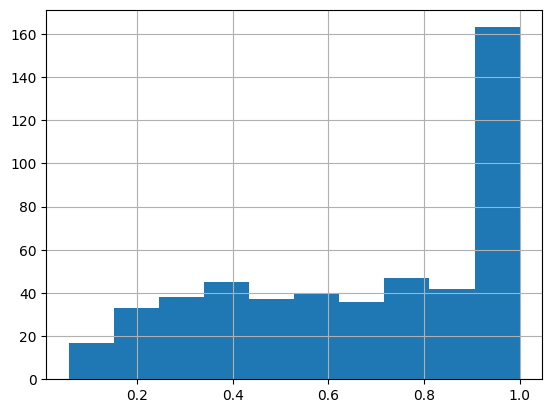

In [66]:
print(grades["Grade"].min())
print(grades["Grade"].max())
print(grades["Grade"].hist(bins=10))
test = grades[grades["Grade"]>1900]
print(len(test["SubjectID"].unique()))

In [67]:
print(len(grades["SubjectID"].unique()))

498


In [68]:
print(subject_feautres_z.columns)
print(grades.columns)

Index(['SubjectID', 'ActiveTime_mean', 'PassiveTime_mean', 'TotalTime_mean',
       'ActiveTimeAfterCorrect_mean', '#Breaks_mean', 'StartTime_mean',
       'FirstCorrectTime_mean', 'EndTime_mean', 'Attempts_mean',
       'FirstCorrect_mean', 'EverCorrect_mean', 'Attempted_mean',
       'MaxScore_mean', 'MinScore_mean', 'MeanScore_mean', 'FirstScore_mean',
       'TotalAttempts_mean', 'AtLeatMedianActiveTime_mean',
       'AtLeatMedianMaxScore_mean', 'HadEffort_mean', 'ActiveTime_sum',
       'PassiveTime_sum', 'TotalTime_sum', 'ActiveTimeAfterCorrect_sum',
       '#Breaks_sum', 'StartTime_sum', 'FirstCorrectTime_sum', 'EndTime_sum',
       'Attempts_sum', 'FirstCorrect_sum', 'EverCorrect_sum', 'Attempted_sum',
       'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'FirstScore_sum',
       'TotalAttempts_sum', 'AtLeatMedianActiveTime_sum',
       'AtLeatMedianMaxScore_sum', 'HadEffort_sum', 'loc_sum', 'loc_mean',
       'lloc_sum', 'lloc_mean', 'sloc_sum', 'sloc_mean', 'comments_sum',


In [70]:
grade_merge_cols = [col for col in merge_cols if col in grades.columns]
print(f"Merging on columns: {grade_merge_cols}")

subject_feautres_labeled = pd.merge(
    subject_feautres_z,
    grades[grade_merge_cols + ["Grade"]],
    on=grade_merge_cols,
    how="inner",
)

Merging on columns: [<MainTableColumns.SubjectID: 'SubjectID'>]


In [71]:
print(subject_features.shape)
subject_feautres_labeled.head()

(488, 41)


,SubjectID,ActiveTime_mean,PassiveTime_mean,TotalTime_mean,ActiveTimeAfterCorrect_mean,#Breaks_mean,StartTime_mean,FirstCorrectTime_mean,EndTime_mean,Attempts_mean,...,difficulty_mean,effort_sum,effort_mean,time_sum,time_mean,bugs_sum,bugs_mean,avg_cc_sum,avg_cc_mean,Grade
0,007f6785-388a-4dee-8cc8-e1c903fd78e2,-0.501077,-0.706592,-0.683069,-0.380949,-0.398482,-0.887159,-0.874252,-0.929574,-0.774276,...,-0.213728,-0.166333,-0.436362,-0.166333,-0.436362,-0.038245,-0.435714,-1.027871,NaN,1.0000
1,00c3a4b3-fc20-4d16-8b10-8e3d00938ba9,0.499957,1.331156,1.017075,1.403077,-0.208738,-1.283588,-1.247832,-0.743004,0.612565,...,-0.481256,0.475863,0.189945,0.475863,0.189945,0.491053,0.198403,1.038457,0.122502,0.7580
2,01c4ce91-6adb-4380-b6d4-9f0e2ab023e6,1.798077,1.828903,1.896533,1.926068,0.419505,0.822367,0.807792,0.535344,2.069225,...,-0.562256,-0.325982,0.767941,-0.325982,0.767941,-0.912638,0.192611,-1.027871,NaN,0.3136
3,021e499a-be6a-4b9a-8bcc-d5a2324e82fd,-0.218974,-0.087675,-0.188542,-0.244824,-0.068346,-0.465349,-0.438420,-0.513584,0.240266,...,-0.134045,1.798541,1.000223,1.798541,1.000223,2.028147,1.294570,1.038457,0.122502,0.9080
4,0256fa1f-5ccc-4fc9-ae02-ee6743909347,-0.021796,-0.540387,-0.414313,-0.144120,-0.451771,2.261024,2.248206,1.670786,-0.062644,...,-0.770840,-2.078021,-1.225920,-2.078021,-1.225920,-2.526524,-1.701550,-1.027871,NaN,0.3160


In [72]:
subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().describe()

count    481.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: Grade, dtype: float64

In [73]:
print(subject_feautres_labeled.columns)

Index(['SubjectID', 'ActiveTime_mean', 'PassiveTime_mean', 'TotalTime_mean',
       'ActiveTimeAfterCorrect_mean', '#Breaks_mean', 'StartTime_mean',
       'FirstCorrectTime_mean', 'EndTime_mean', 'Attempts_mean',
       'FirstCorrect_mean', 'EverCorrect_mean', 'Attempted_mean',
       'MaxScore_mean', 'MinScore_mean', 'MeanScore_mean', 'FirstScore_mean',
       'TotalAttempts_mean', 'AtLeatMedianActiveTime_mean',
       'AtLeatMedianMaxScore_mean', 'HadEffort_mean', 'ActiveTime_sum',
       'PassiveTime_sum', 'TotalTime_sum', 'ActiveTimeAfterCorrect_sum',
       '#Breaks_sum', 'StartTime_sum', 'FirstCorrectTime_sum', 'EndTime_sum',
       'Attempts_sum', 'FirstCorrect_sum', 'EverCorrect_sum', 'Attempted_sum',
       'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'FirstScore_sum',
       'TotalAttempts_sum', 'AtLeatMedianActiveTime_sum',
       'AtLeatMedianMaxScore_sum', 'HadEffort_sum', 'loc_sum', 'loc_mean',
       'lloc_sum', 'lloc_mean', 'sloc_sum', 'sloc_mean', 'comments_sum',


In [74]:
assert subject_feautres_labeled.groupby(grade_merge_cols).Grade.count().max() == 1

In [ ]:
if config.name in ["codebench", "codeworkout"]:
    outliers_students = subject_features_labeled[subject_features_labeled["FirstCorrect_mean"] > 1.5]
    print(len(outliers_students["SubjectID"].unique()))
    subject_features_labeled = subject_features_labeled[~subject_features_labeled["SubjectID"].isin(outliers_students["SubjectID"].unique())]
    print(len(subject_features_labeled["SubjectID"].unique()))

In [76]:
out_dir = os.path.join("..", "..", "..", "analysis", "features")
print(len(subject_feautres_labeled))
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
subject_feautres_labeled.to_csv(os.path.join(out_dir, f"{config.name}.csv"), index=False)

481


In [77]:
print(subject_feautres_labeled.columns)

Index(['SubjectID', 'ActiveTime_mean', 'PassiveTime_mean', 'TotalTime_mean',
       'ActiveTimeAfterCorrect_mean', '#Breaks_mean', 'StartTime_mean',
       'FirstCorrectTime_mean', 'EndTime_mean', 'Attempts_mean',
       'FirstCorrect_mean', 'EverCorrect_mean', 'Attempted_mean',
       'MaxScore_mean', 'MinScore_mean', 'MeanScore_mean', 'FirstScore_mean',
       'TotalAttempts_mean', 'AtLeatMedianActiveTime_mean',
       'AtLeatMedianMaxScore_mean', 'HadEffort_mean', 'ActiveTime_sum',
       'PassiveTime_sum', 'TotalTime_sum', 'ActiveTimeAfterCorrect_sum',
       '#Breaks_sum', 'StartTime_sum', 'FirstCorrectTime_sum', 'EndTime_sum',
       'Attempts_sum', 'FirstCorrect_sum', 'EverCorrect_sum', 'Attempted_sum',
       'MaxScore_sum', 'MinScore_sum', 'MeanScore_sum', 'FirstScore_sum',
       'TotalAttempts_sum', 'AtLeatMedianActiveTime_sum',
       'AtLeatMedianMaxScore_sum', 'HadEffort_sum', 'loc_sum', 'loc_mean',
       'lloc_sum', 'lloc_mean', 'sloc_sum', 'sloc_mean', 'comments_sum',


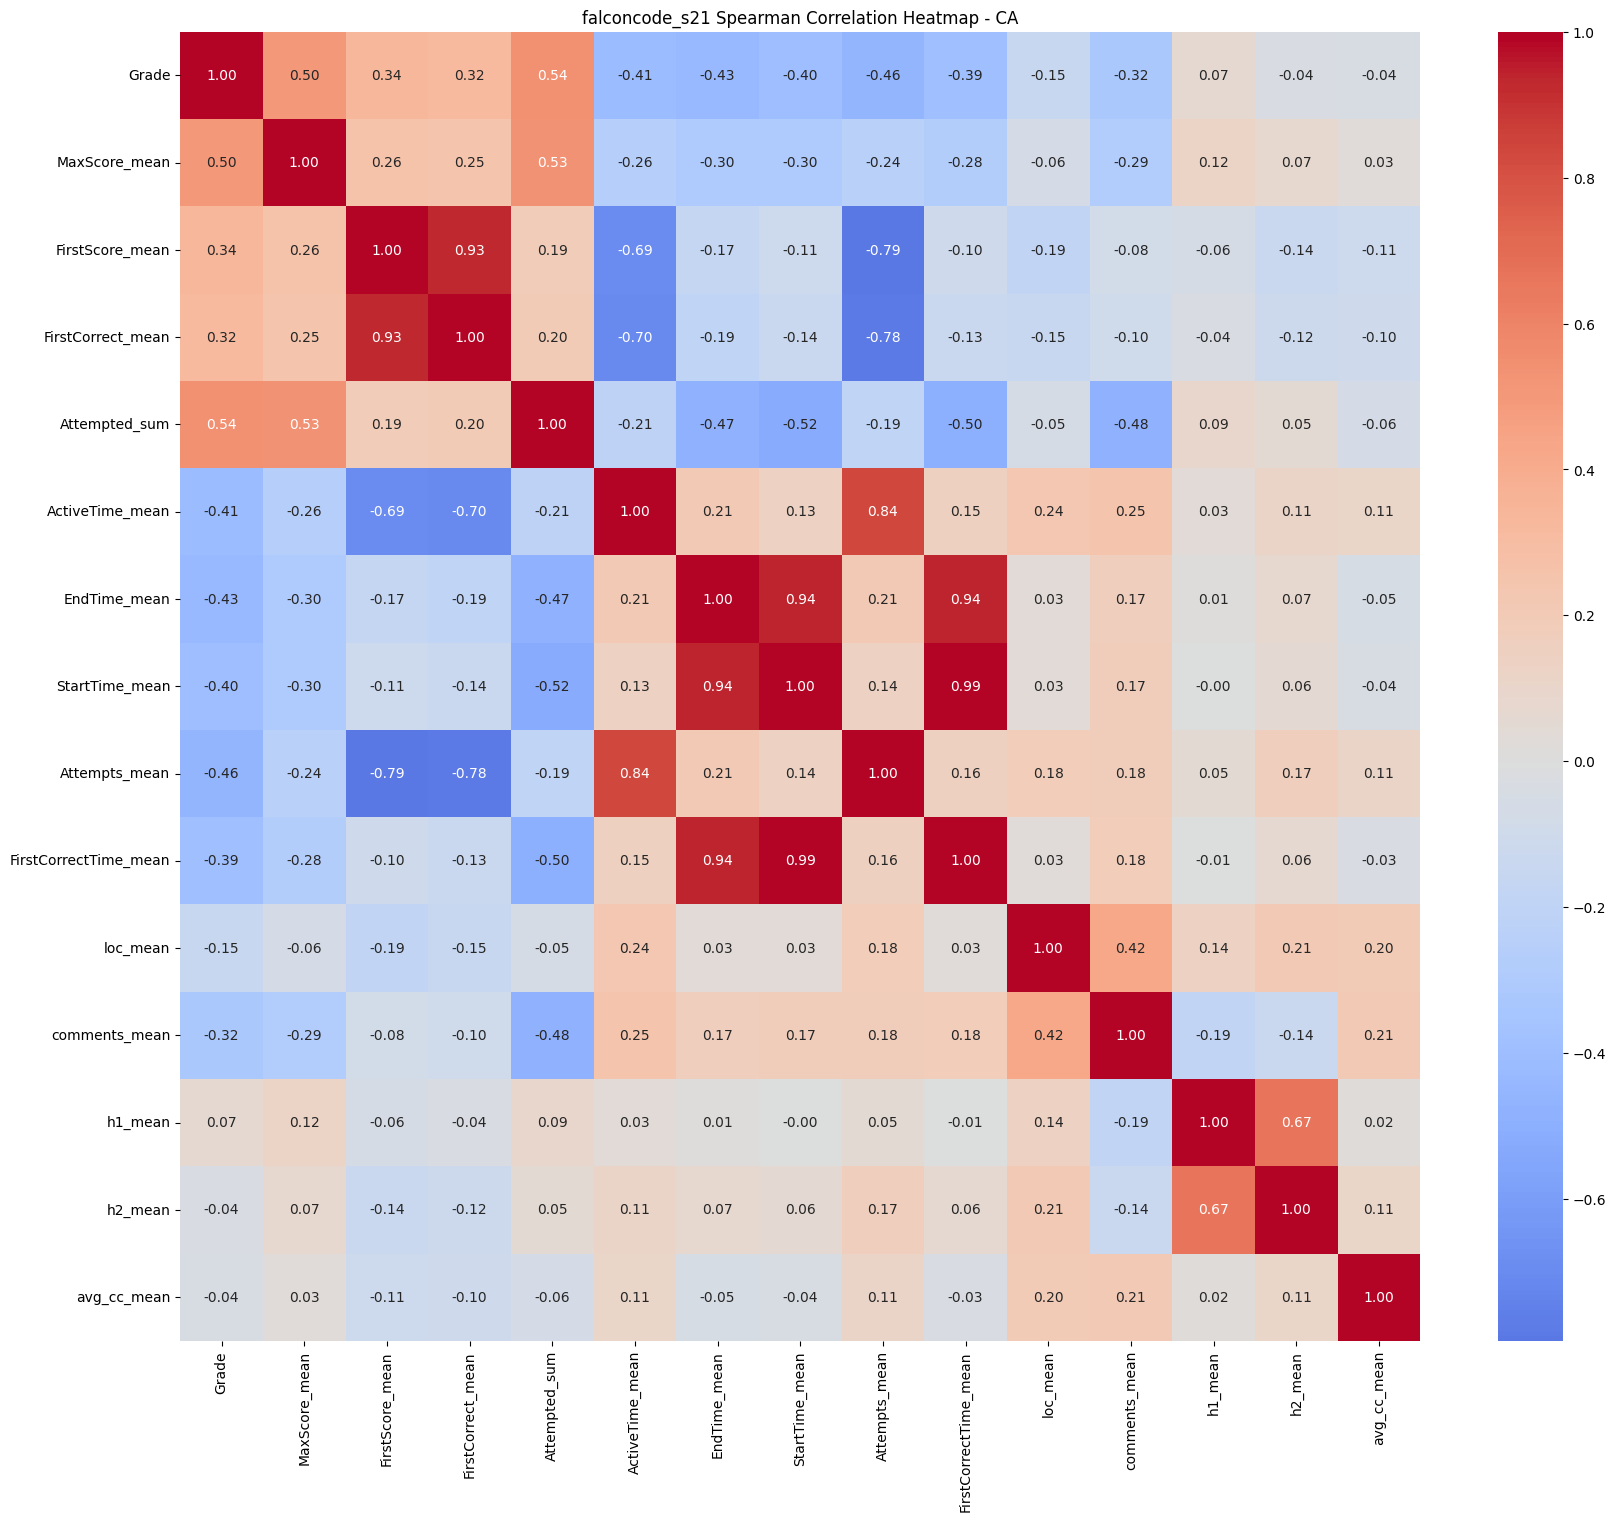

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns you're interested in
cols = ['Grade',  'MaxScore_mean', 'FirstScore_mean', 'FirstCorrect_mean' , 'Attempted_sum', 'ActiveTime_mean', 'EndTime_mean' , 'StartTime_mean', 'Attempts_mean' ,
'FirstCorrectTime_mean',  'loc_mean', 'comments_mean', 'h1_mean', 'h2_mean', 'avg_cc_mean']

spearman_corr = subject_feautres_labeled[cols].corr(method='spearman')

plt.figure(figsize=(20, 17))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title(config.name + " Spearman Correlation Heatmap - CA")
plt.show()